# Airbnb Price Prediction — EDA

## 1 · Load Data

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [32]:
df = pd.read_csv('../data/Airbnb_Data.csv')
df.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


## 2 · Shape & Types

In [33]:
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.info()

Shape: 74,111 rows x 29 columns
<class 'pandas.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  str    
 3   room_type               74111 non-null  str    
 4   amenities               74111 non-null  str    
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  str    
 8   cancellation_policy     74111 non-null  str    
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  str    
 11  description             74111 non-null  str    
 12  first_review            58247 non-null  str    
 13  host_has_profile_pic    73923 non-null  str    
 14  host_identity_ver

In [34]:
dtype_df = df.dtypes.value_counts().reset_index()
dtype_df.columns = ['dtype', 'count']
dtype_df

,dtype,count
0,str,18
1,float64,7
2,int64,3
3,bool,1


## 3 · Missing Values

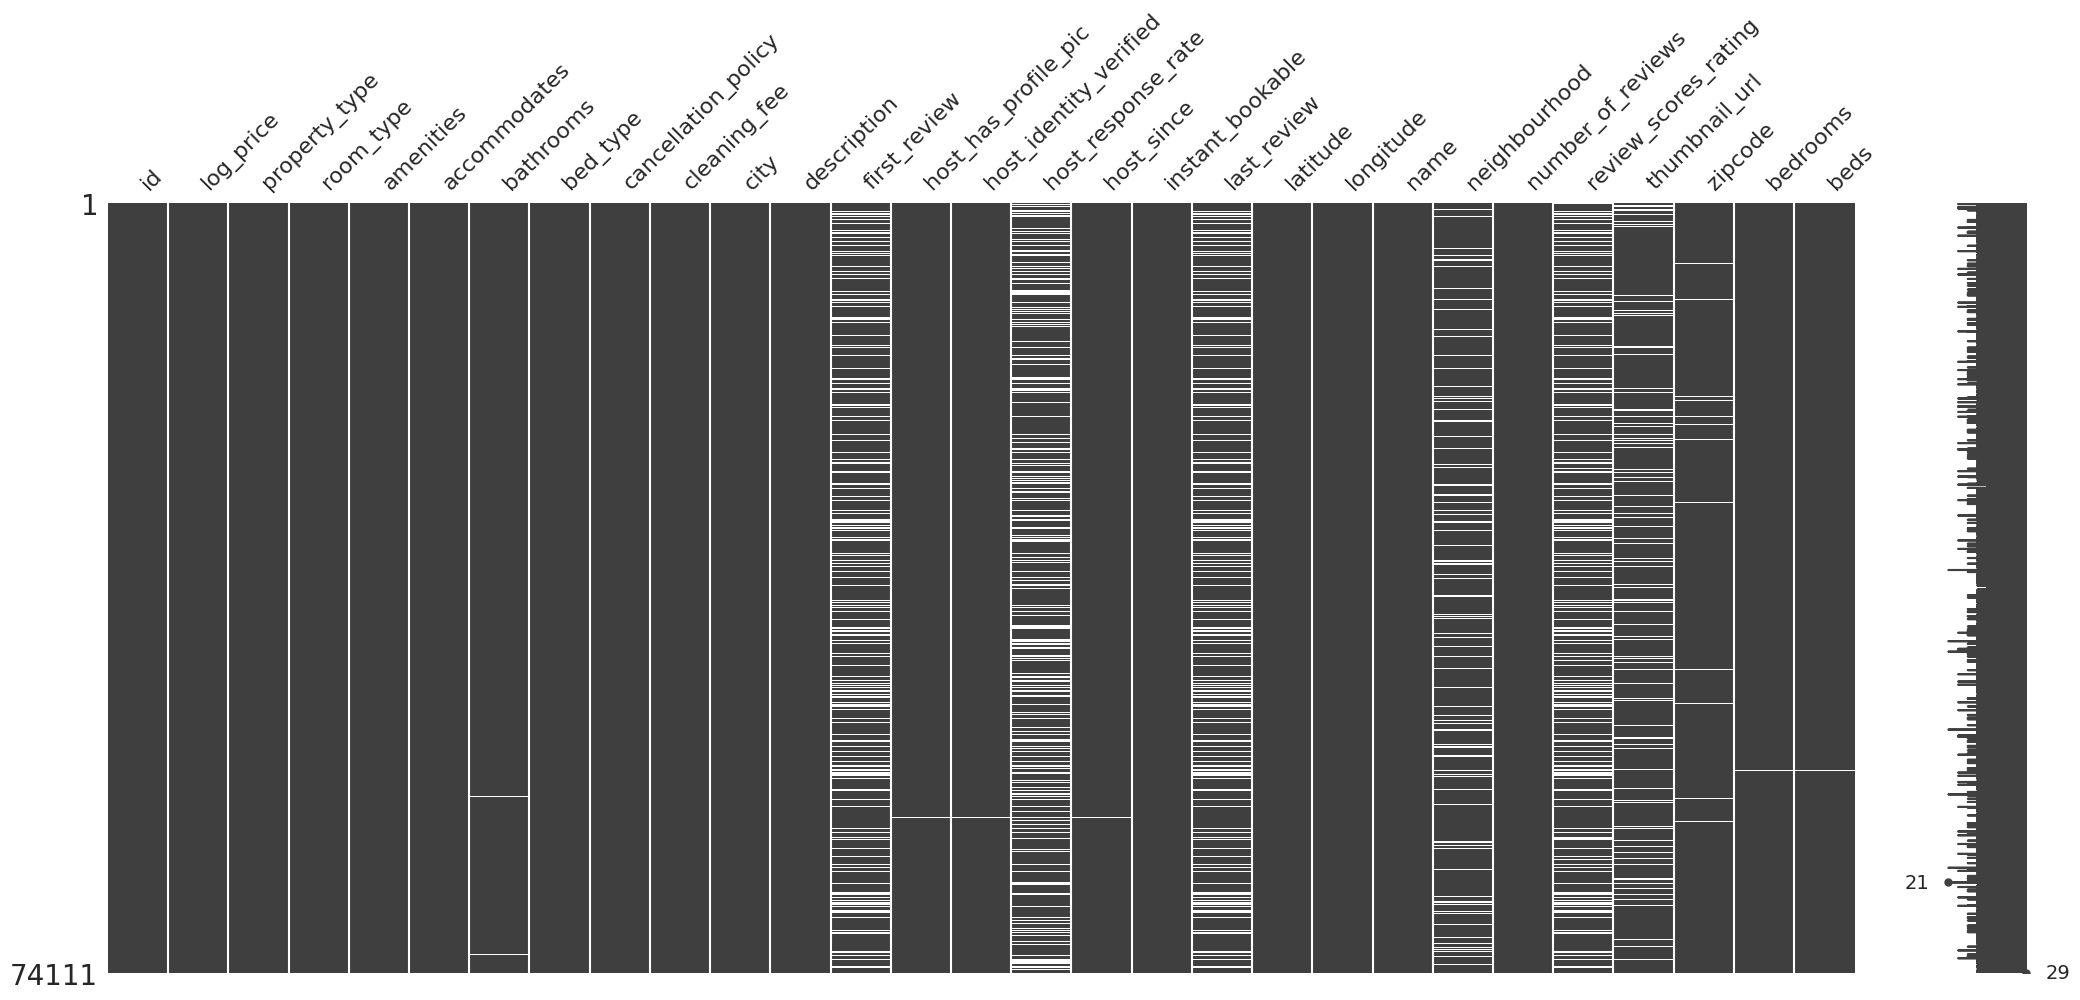

In [35]:
msno.matrix(df)
plt.show()

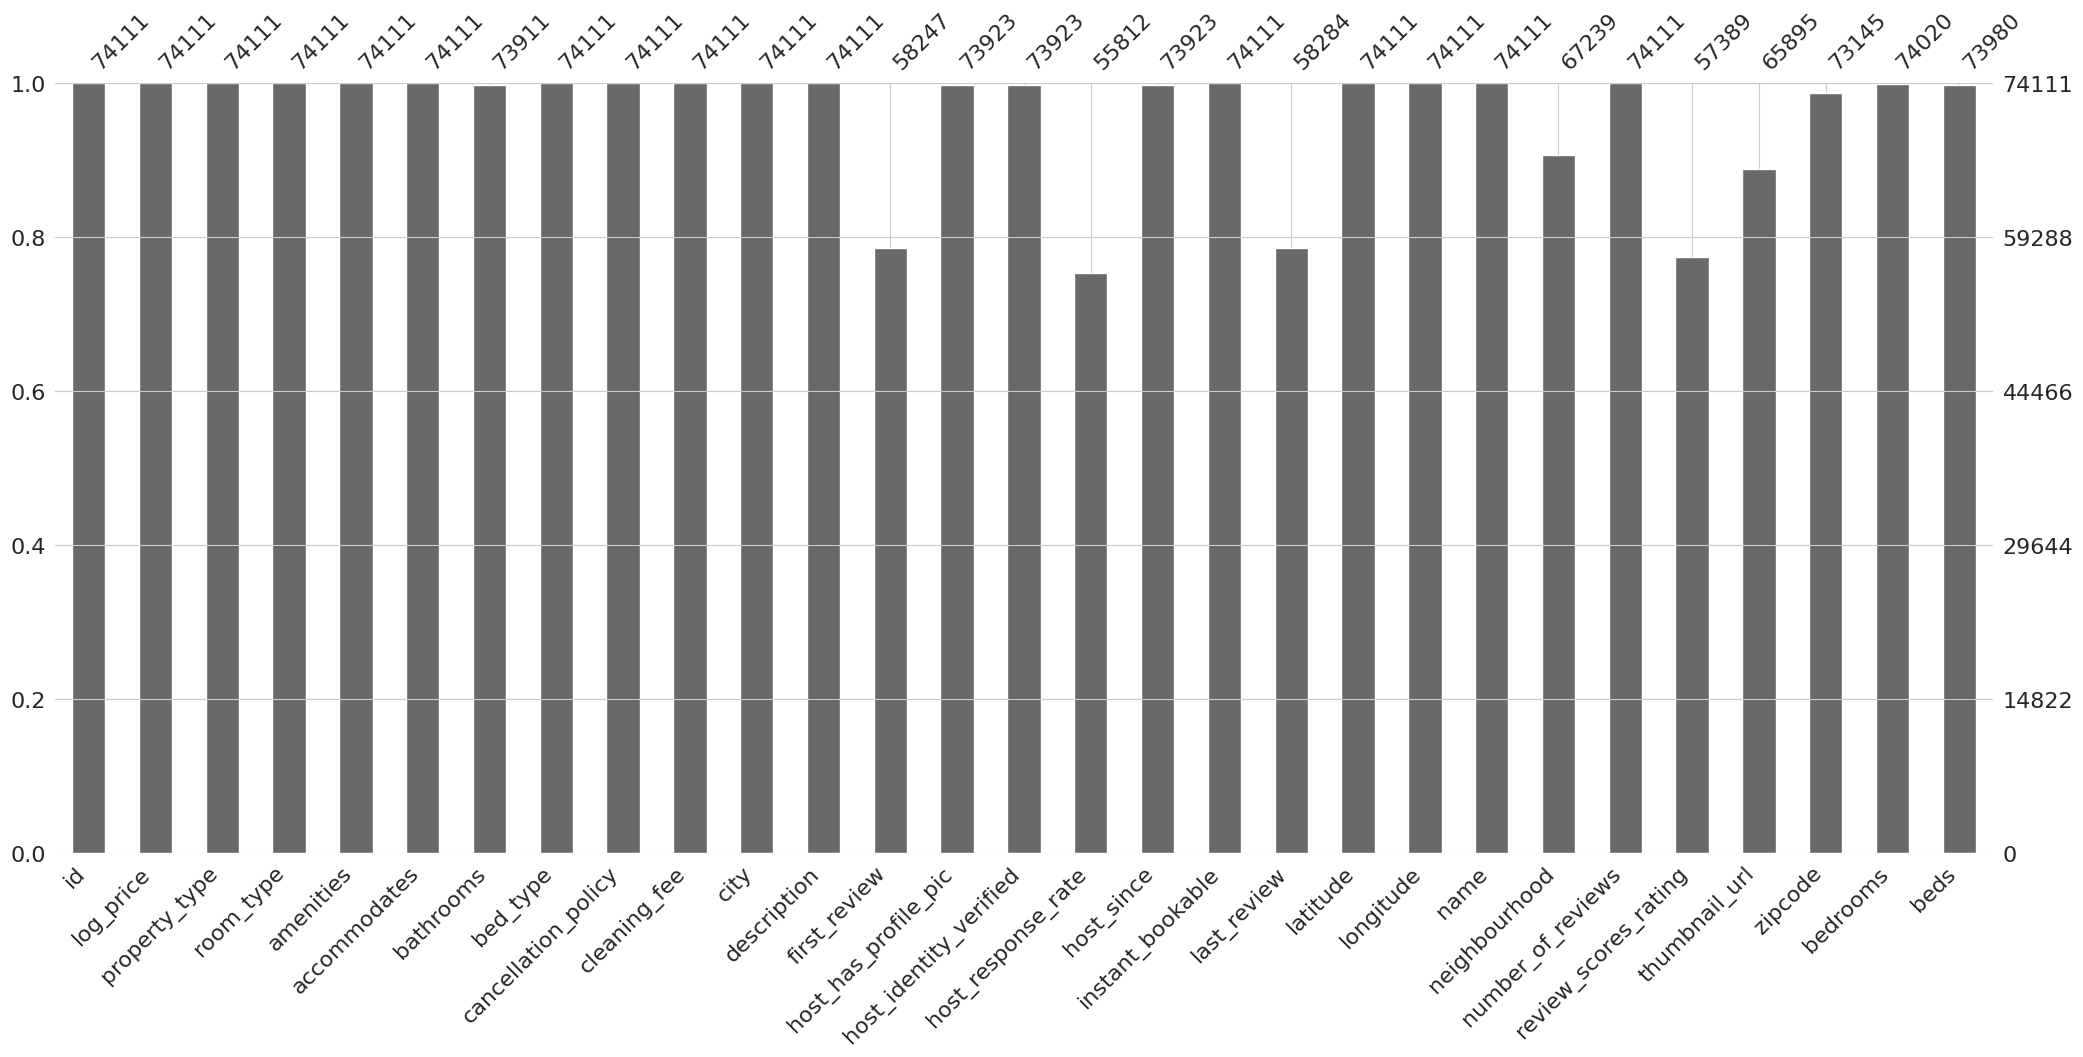

In [36]:
msno.bar(df)
plt.show()

In [37]:
missing = df.isnull().sum().sort_values(ascending=False)
pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'null_count': missing, 'null_pct': pct})
missing_df[missing_df['null_count'] > 0]

,null_count,null_pct
host_response_rate,18299,24.69
review_scores_rating,16722,22.56
first_review,15864,21.41
last_review,15827,21.36
thumbnail_url,8216,11.09
neighbourhood,6872,9.27
zipcode,966,1.30
bathrooms,200,0.27
host_identity_verified,188,0.25
host_has_profile_pic,188,0.25


## 4 · Target Distribution

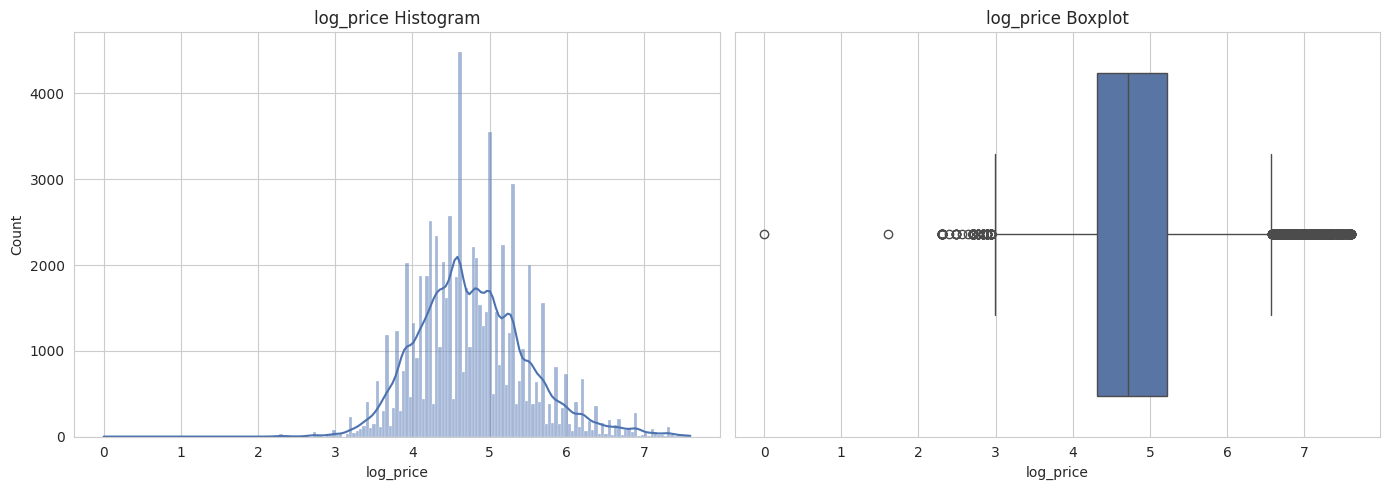

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['log_price'], kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('log_price Histogram')
axes[0].set_xlabel('log_price')

sns.boxplot(x=df['log_price'], ax=axes[1], color='#4C72B0')
axes[1].set_title('log_price Boxplot')

plt.tight_layout()
plt.show()

In [39]:
df['log_price'].describe()

count    74111.000000
mean         4.782069
std          0.717394
min          0.000000
25%          4.317488
50%          4.709530
75%          5.220356
max          7.600402
Name: log_price, dtype: float64

In [40]:
print(f"Skewness:  {df['log_price'].skew():.4f}")
print(f"Kurtosis:  {df['log_price'].kurtosis():.4f}")

Skewness:  0.5147
Kurtosis:  0.6606


## 5 · Numeric Features

In [41]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
id,74111.0,1.126662e+07,6.081735e+06,344.000000,6.261964e+06,1.225415e+07,1.640226e+07,2.123090e+07
log_price,74111.0,4.782069e+00,7.173938e-01,0.000000,4.317488e+00,4.709530e+00,5.220356e+00,7.600402e+00
accommodates,74111.0,3.155146e+00,2.153589e+00,1.000000,2.000000e+00,2.000000e+00,4.000000e+00,1.600000e+01
bathrooms,73911.0,1.235263e+00,5.820441e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,8.000000e+00
latitude,74111.0,3.844596e+01,3.080167e+00,33.338905,3.412791e+01,4.066214e+01,4.074610e+01,4.239044e+01
longitude,74111.0,-9.239753e+01,2.170532e+01,-122.511500,-1.183424e+02,-7.699696e+01,-7.395466e+01,-7.098505e+01
number_of_reviews,74111.0,2.090057e+01,3.782864e+01,0.000000,1.000000e+00,6.000000e+00,2.300000e+01,6.050000e+02
review_scores_rating,57389.0,9.406736e+01,7.836556e+00,20.000000,9.200000e+01,9.600000e+01,1.000000e+02,1.000000e+02
bedrooms,74020.0,1.265793e+00,8.521435e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01
beds,73980.0,1.710868e+00,1.254142e+00,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,1.800000e+01


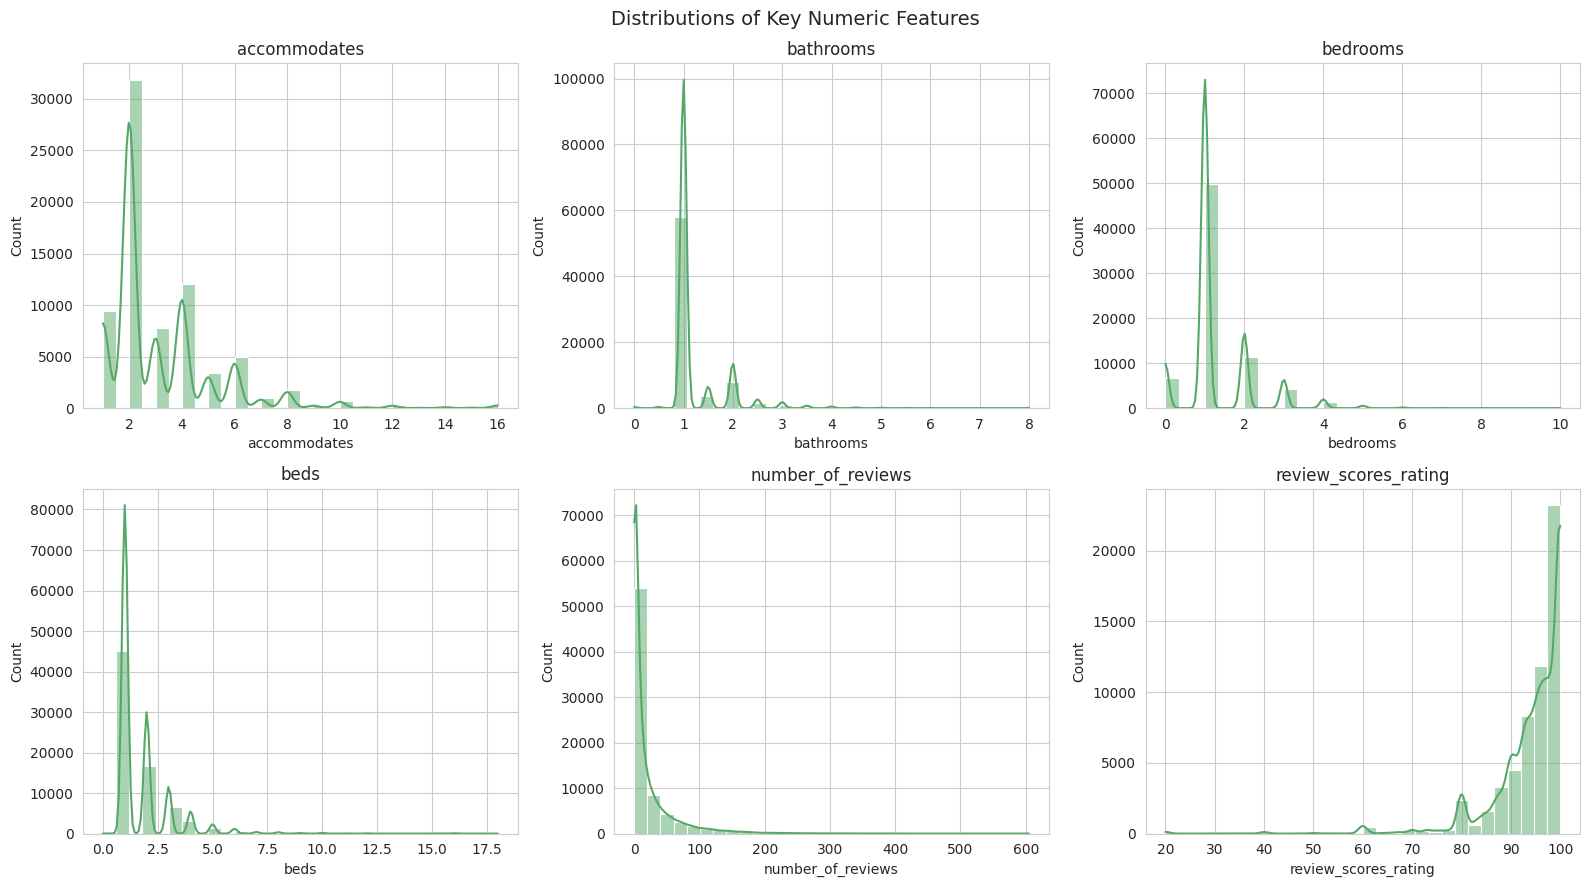

In [42]:
key_numerics = ['accommodates', 'bathrooms', 'bedrooms', 'beds',
                'number_of_reviews', 'review_scores_rating']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, key_numerics):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='#55A868', bins=30)
    ax.set_title(col)

plt.suptitle('Distributions of Key Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

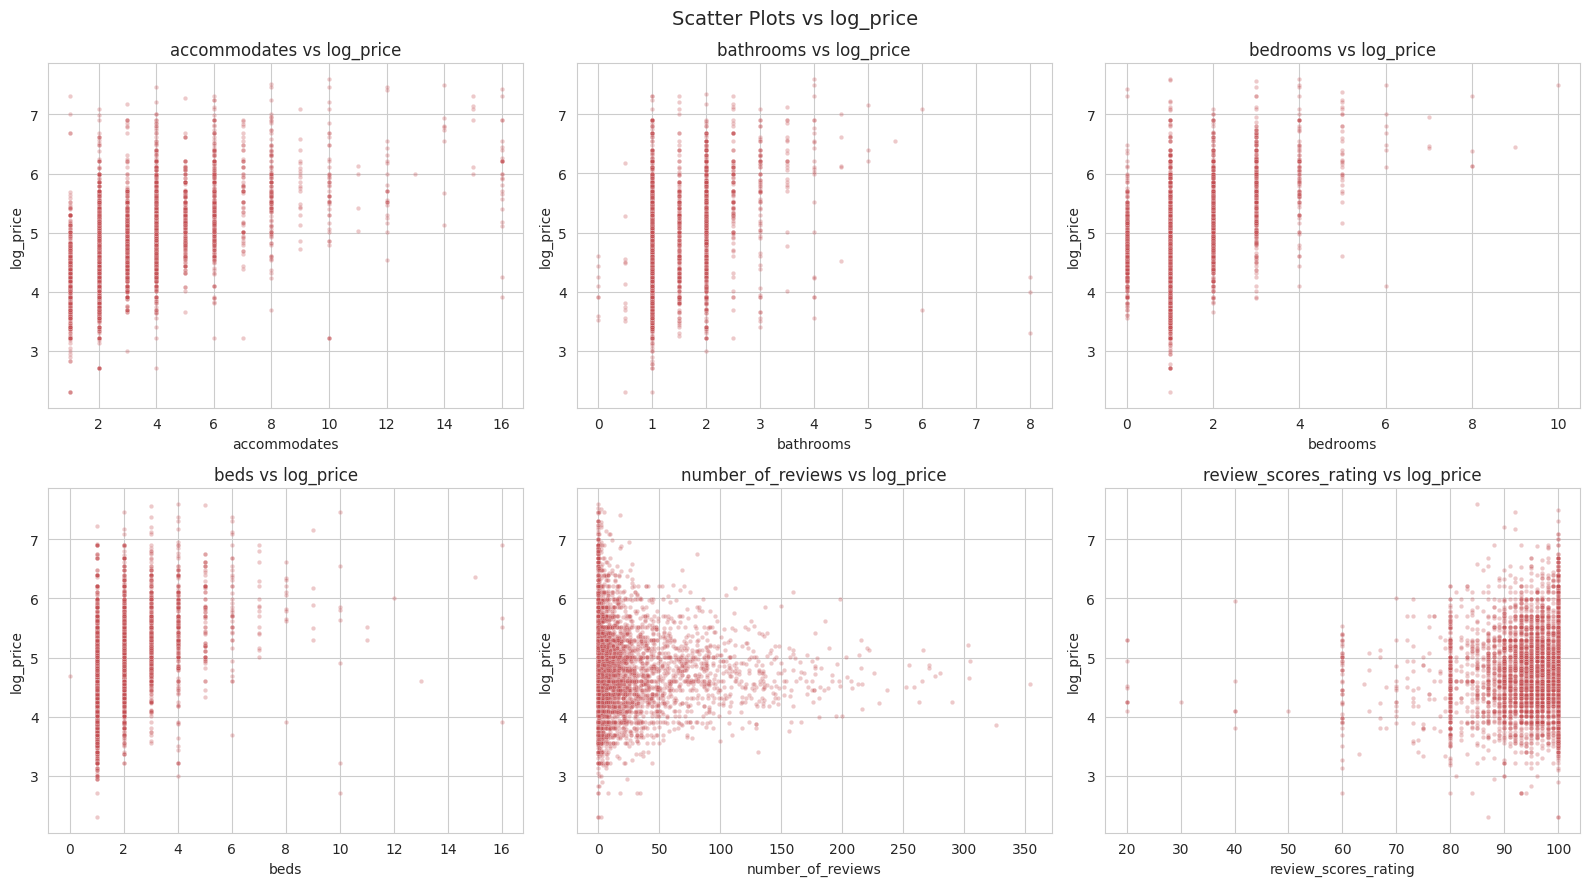

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, key_numerics):
    sample = df[[col, 'log_price']].dropna().sample(min(5000, len(df)), random_state=42)
    sns.scatterplot(x=col, y='log_price', data=sample, ax=ax, alpha=0.3, s=10, color='#C44E52')
    ax.set_title(f'{col} vs log_price')

plt.suptitle('Scatter Plots vs log_price', fontsize=14)
plt.tight_layout()
plt.show()

## 6 · Geospatial

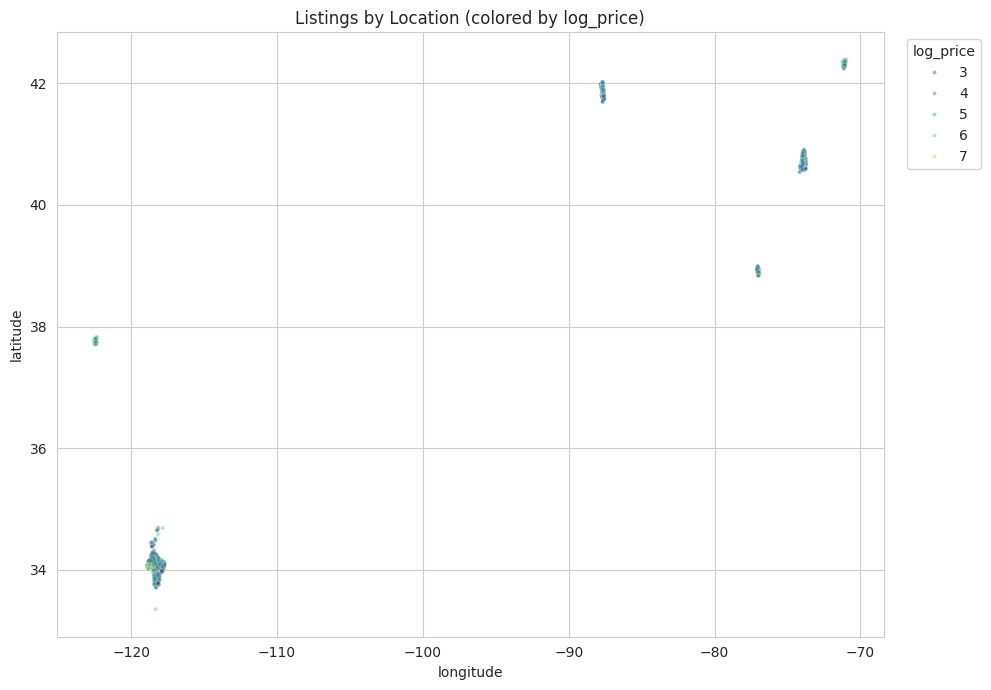

In [44]:
fig, ax = plt.subplots(figsize=(10, 7))
sample = df.sample(10000, random_state=42)
sns.scatterplot(x='longitude', y='latitude', hue='log_price',
                data=sample, palette='viridis', alpha=0.4, s=8, ax=ax)
ax.set_title('Listings by Location (colored by log_price)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='log_price')
plt.tight_layout()
plt.show()

## 7 · Categorical Features

In [45]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_unique = df[cat_cols].nunique().sort_values(ascending=False).reset_index()
cat_unique.columns = ['column', 'unique_count']
cat_unique

,column,unique_count
0,description,73479
1,name,73359
2,amenities,67122
3,thumbnail_url,65883
4,host_since,3087
5,first_review,2554
6,last_review,1371
7,zipcode,769
8,neighbourhood,619
9,host_response_rate,80


### Room Type

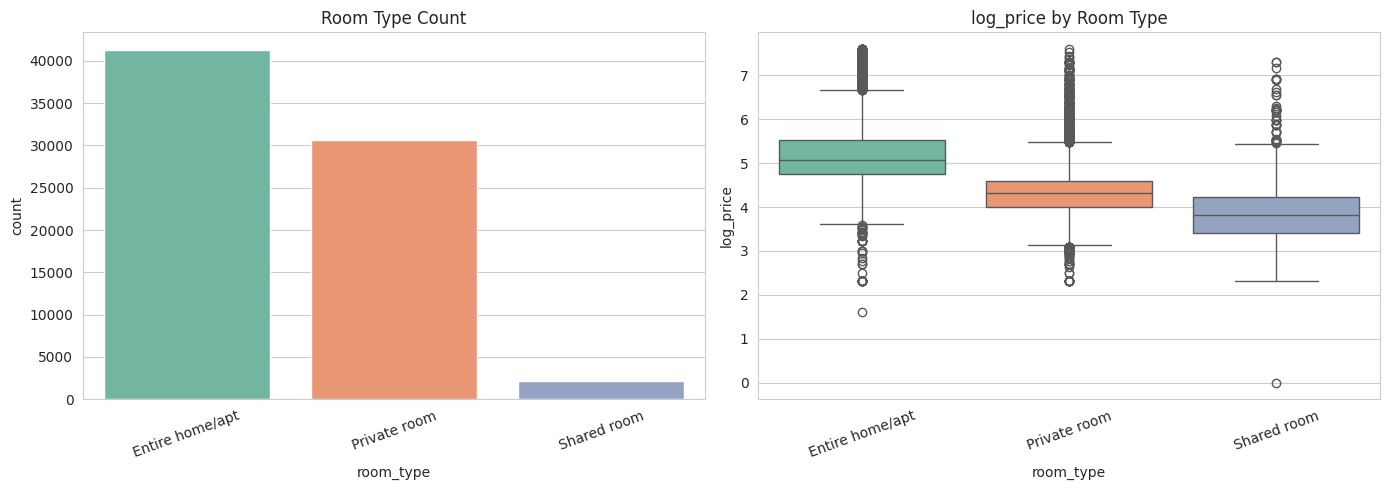

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = df['room_type'].value_counts().index
sns.countplot(x='room_type', data=df, order=order, ax=axes[0], palette='Set2')
axes[0].set_title('Room Type Count')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(x='room_type', y='log_price', data=df, order=order, ax=axes[1], palette='Set2')
axes[1].set_title('log_price by Room Type')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [47]:
df.groupby('room_type')['log_price'].agg(['mean', 'median', 'count']).round(3)

,mean,median,count
room_type,,,
Entire home/apt,5.167,5.075,41310
Private room,4.328,4.317,30638
Shared room,3.862,3.807,2163


### Property Type

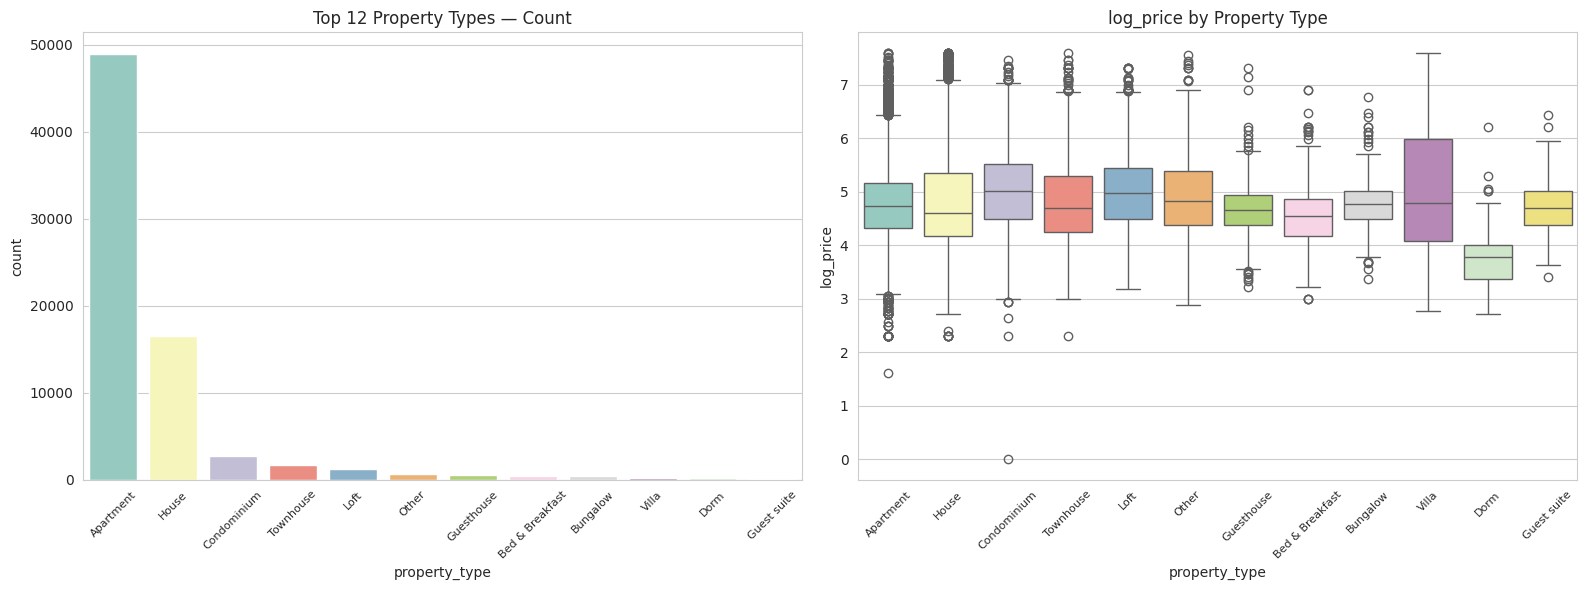

In [48]:
top12 = df['property_type'].value_counts().head(12).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(x='property_type', data=df[df['property_type'].isin(top12)],
              order=top12, ax=axes[0], palette='Set3')
axes[0].set_title('Top 12 Property Types — Count')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)

sns.boxplot(x='property_type', y='log_price',
            data=df[df['property_type'].isin(top12)],
            order=top12, ax=axes[1], palette='Set3')
axes[1].set_title('log_price by Property Type')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

### City

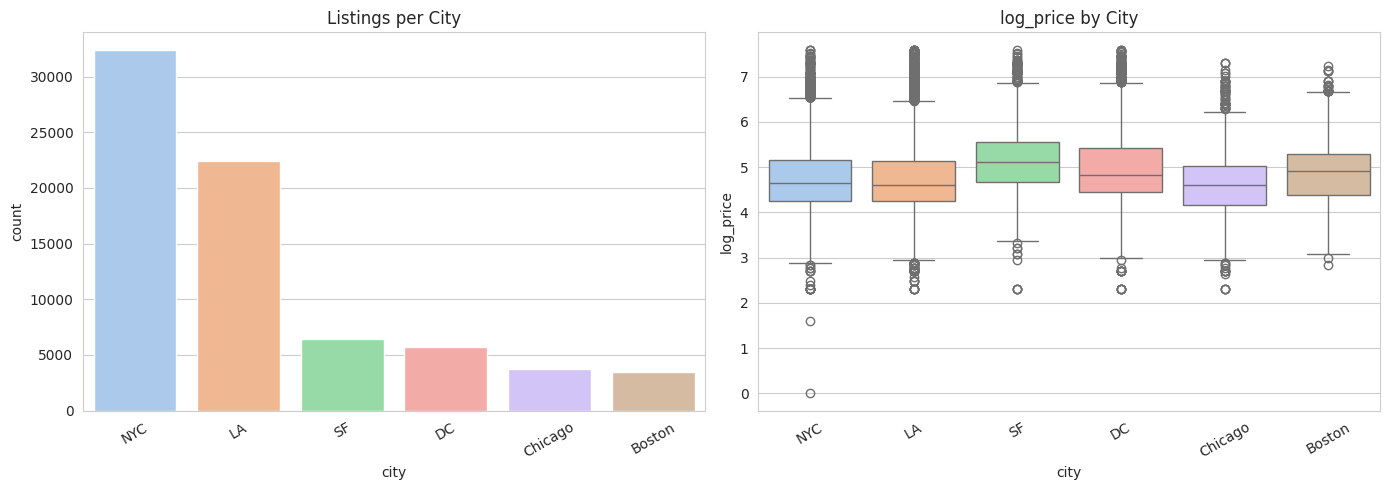

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

city_order = df['city'].value_counts().index
sns.countplot(x='city', data=df, order=city_order, ax=axes[0], palette='pastel')
axes[0].set_title('Listings per City')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(x='city', y='log_price', data=df, order=city_order, ax=axes[1], palette='pastel')
axes[1].set_title('log_price by City')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [50]:
df.groupby('city')['log_price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False).round(3)

,mean,median,count
city,,,
SF,5.170,5.106,6434
DC,4.987,4.828,5688
Boston,4.884,4.913,3468
LA,4.720,4.605,22453
NYC,4.719,4.654,32349
Chicago,4.620,4.595,3719


### Cancellation Policy

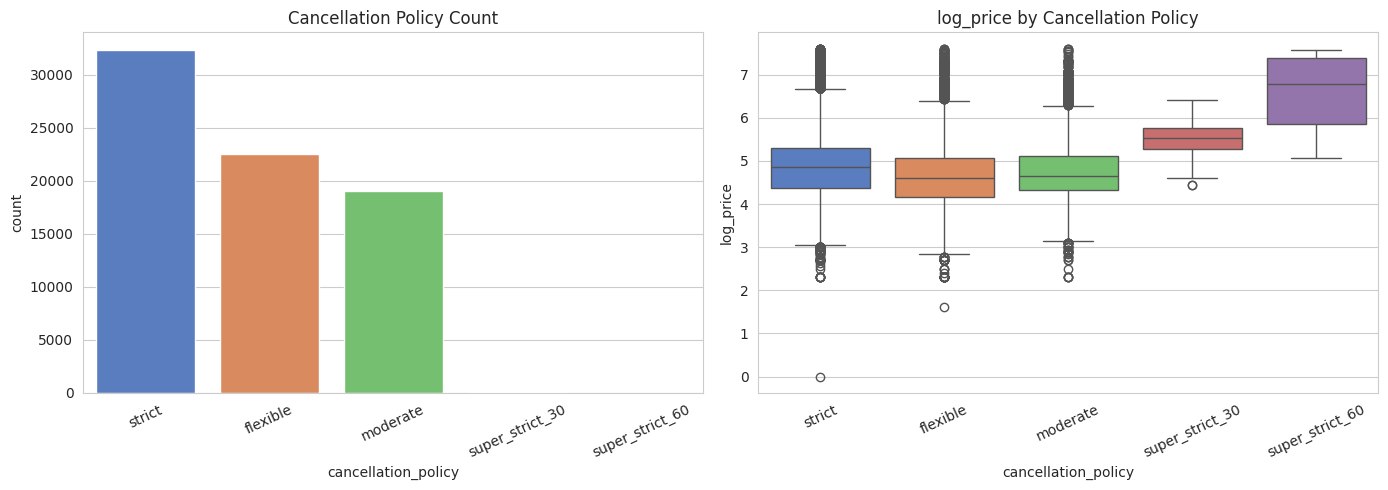

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cp_order = df['cancellation_policy'].value_counts().index
sns.countplot(x='cancellation_policy', data=df, order=cp_order, ax=axes[0], palette='muted')
axes[0].set_title('Cancellation Policy Count')
axes[0].tick_params(axis='x', rotation=25)

sns.boxplot(x='cancellation_policy', y='log_price', data=df, order=cp_order, ax=axes[1], palette='muted')
axes[1].set_title('log_price by Cancellation Policy')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

### Binary Flags

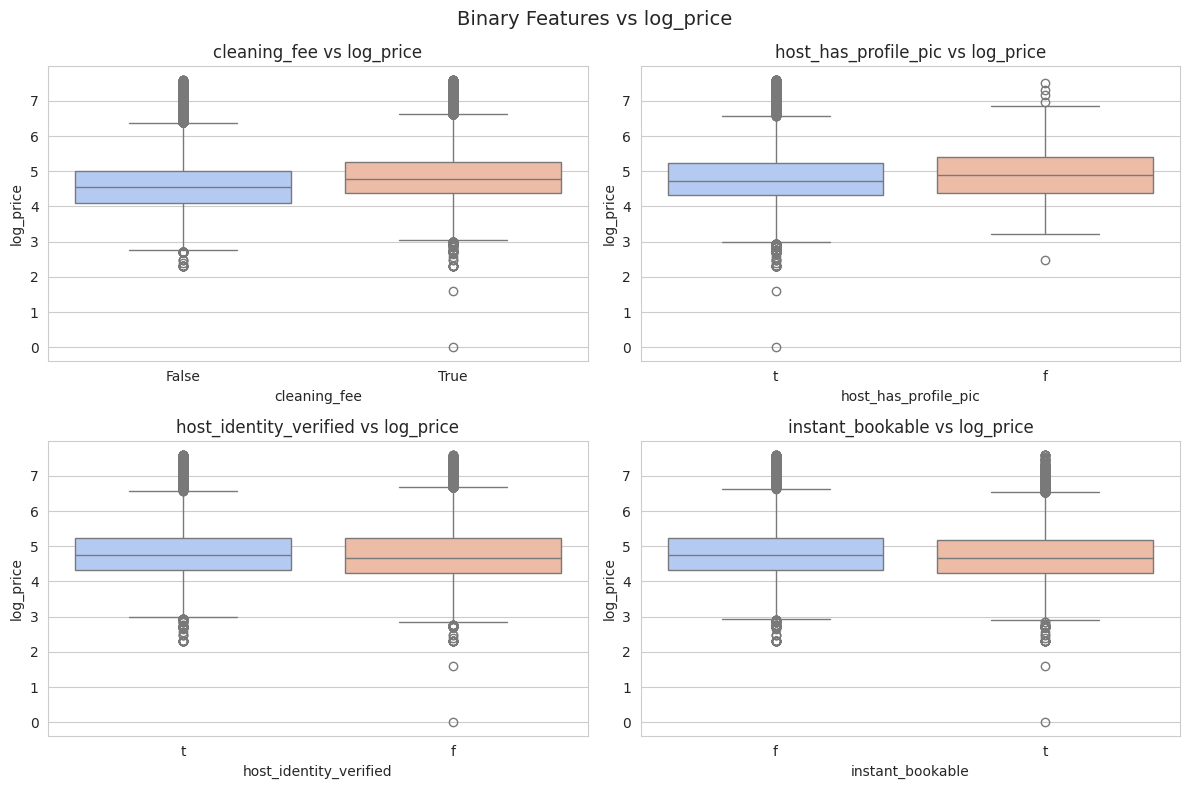

In [52]:
binary_cols = ['cleaning_fee', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, binary_cols):
    sns.boxplot(x=col, y='log_price', data=df, ax=ax, palette='coolwarm')
    ax.set_title(f'{col} vs log_price')

plt.suptitle('Binary Features vs log_price', fontsize=14)
plt.tight_layout()
plt.show()

In [53]:
for col in binary_cols:
    means = df.groupby(col)['log_price'].mean().round(3)
    print(f'\n{col}:')
    print(means)


cleaning_fee:
cleaning_fee
False    4.65
True     4.83
Name: log_price, dtype: float64

host_has_profile_pic:
host_has_profile_pic
f    4.953
t    4.782
Name: log_price, dtype: float64

host_identity_verified:
host_identity_verified
f    4.757
t    4.794
Name: log_price, dtype: float64

instant_bookable:
instant_bookable
f    4.801
t    4.729
Name: log_price, dtype: float64


## 8 · Amenities

In [54]:
df['amenities_list'] = df['amenities'].apply(lambda x: [a.strip(' "').lower() for a in x.strip('{}').split(',')] if pd.notna(x) and x != '{}' else [])
df['amenity_count'] = df['amenities_list'].apply(len)

print(f'Average amenities per listing: {df["amenity_count"].mean():.1f}')
print(f'Max amenities: {df["amenity_count"].max()}')
print(f'Min amenities: {df["amenity_count"].min()}')

Average amenities per listing: 17.6
Max amenities: 86
Min amenities: 0


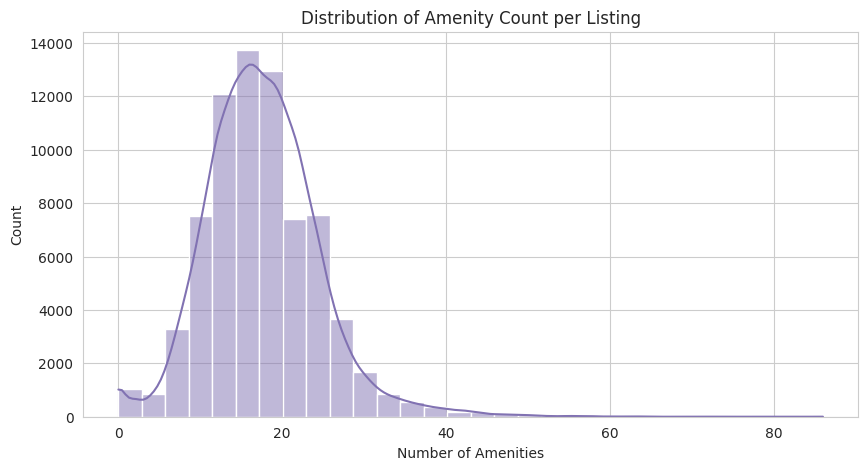

In [55]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['amenity_count'], kde=True, bins=30, ax=ax, color='#8172B2')
ax.set_title('Distribution of Amenity Count per Listing')
ax.set_xlabel('Number of Amenities')
plt.show()

In [56]:
print(f'Correlation (amenity_count, log_price): {df["amenity_count"].corr(df["log_price"]):.4f}')

Correlation (amenity_count, log_price): 0.1941


In [57]:
from collections import Counter

all_amenities = Counter()
for lst in df['amenities_list']:
    all_amenities.update(lst)

amenity_counts = pd.DataFrame(all_amenities.most_common(20), columns=['amenity', 'count'])
amenity_counts

,amenity,count
0,wireless internet,71265
1,kitchen,67526
2,heating,67073
3,essentials,64005
4,smoke detector,61727
5,air conditioning,55210
6,tv,52458
7,shampoo,49465
8,hangers,49173
9,carbon monoxide detector,47190


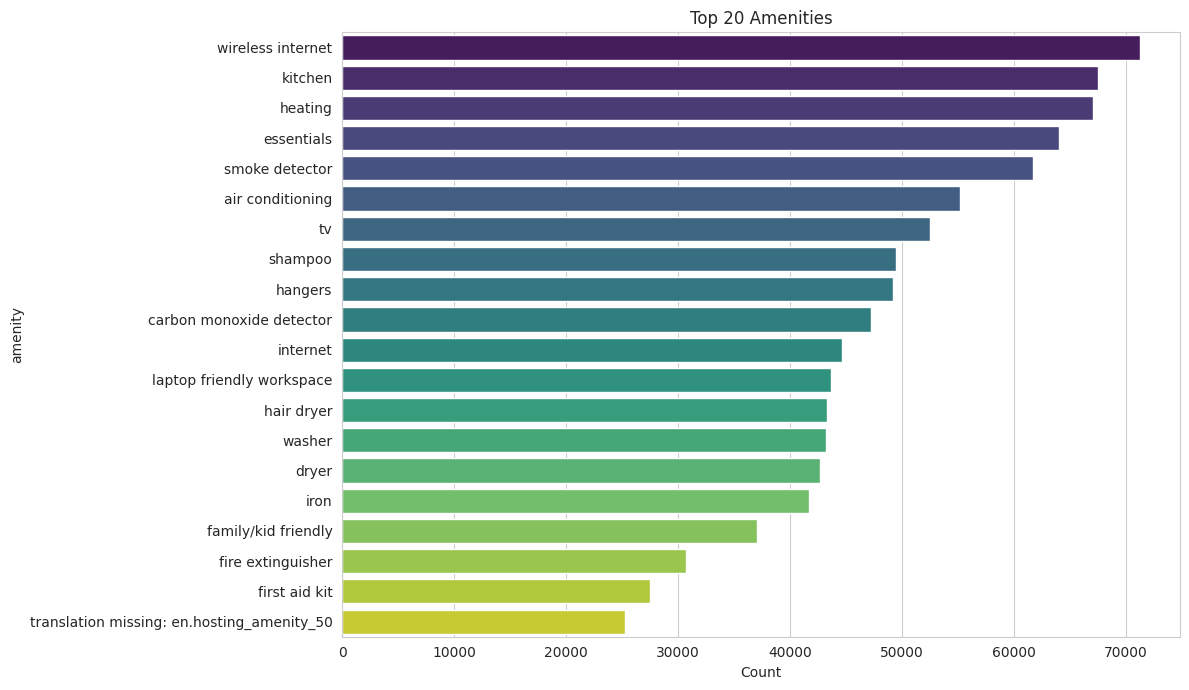

In [58]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x='count', y='amenity', data=amenity_counts, palette='viridis', ax=ax)
ax.set_title('Top 20 Amenities')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

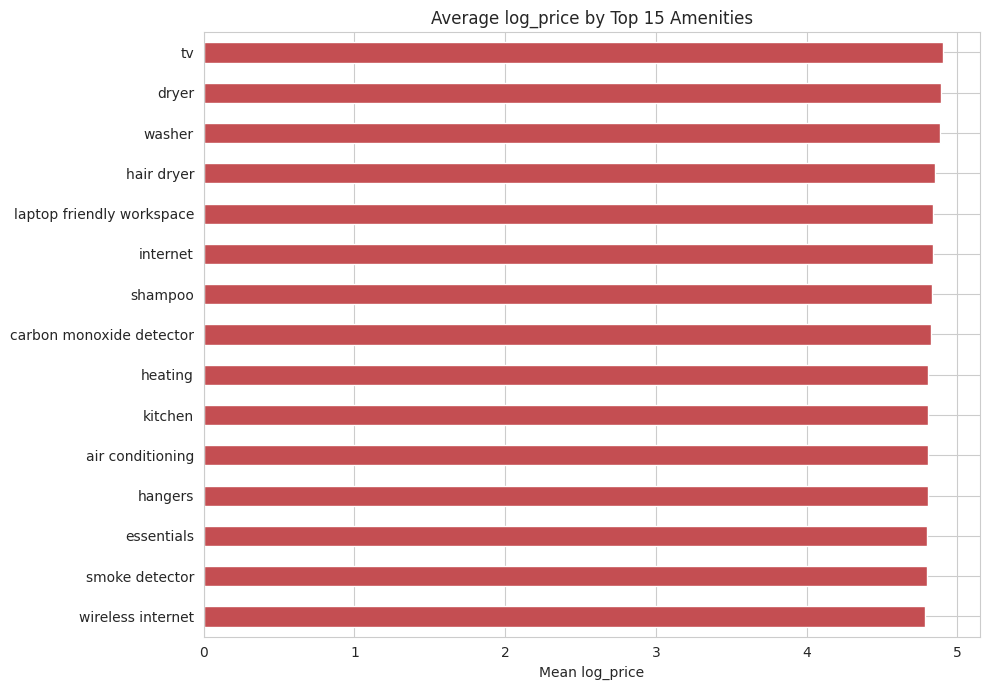

In [59]:
top_amenity_names = [a for a, _ in all_amenities.most_common(15)]

price_by_amenity = {}
for amenity in top_amenity_names:
    mask = df['amenities_list'].apply(lambda lst: amenity in lst)
    price_by_amenity[amenity] = df.loc[mask, 'log_price'].mean()

amenity_price_df = pd.DataFrame.from_dict(price_by_amenity, orient='index', columns=['mean_log_price'])
amenity_price_df = amenity_price_df.sort_values('mean_log_price', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
amenity_price_df.plot(kind='barh', ax=ax, color='#C44E52', legend=False)
ax.set_title('Average log_price by Top 15 Amenities')
ax.set_xlabel('Mean log_price')
plt.tight_layout()
plt.show()

## 9 · Correlations

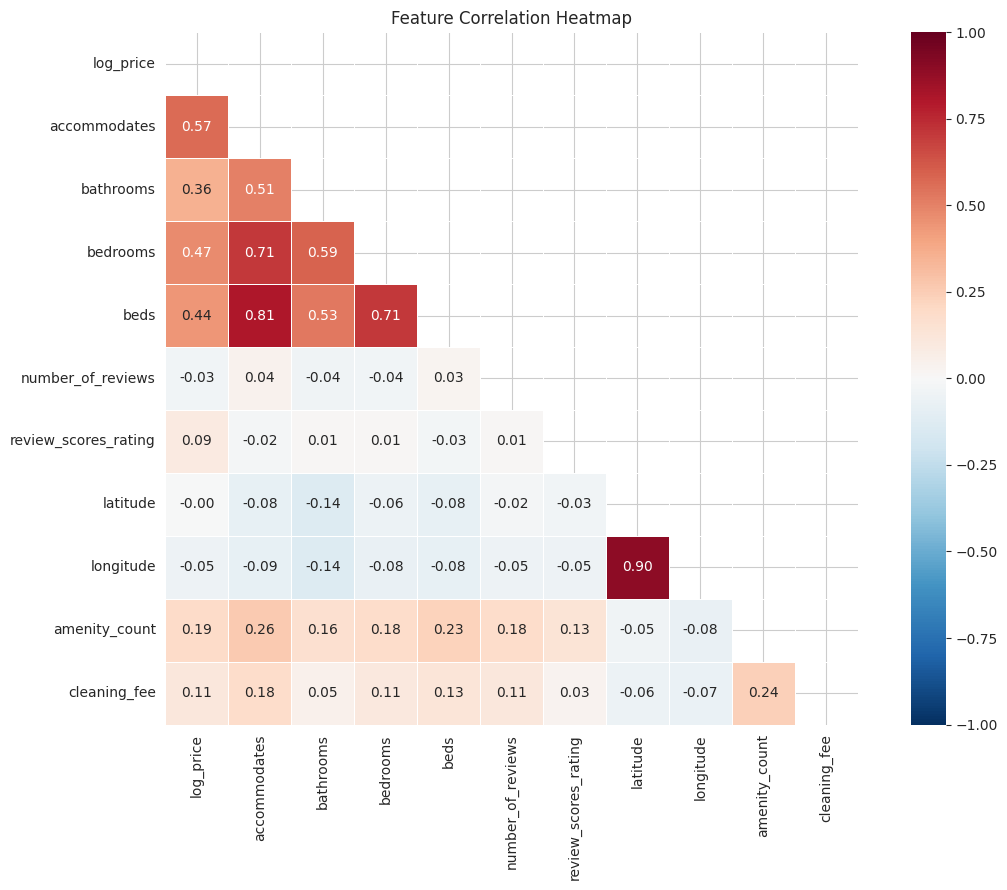

In [60]:
corr_cols = ['log_price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
             'number_of_reviews', 'review_scores_rating', 'latitude', 'longitude',
             'amenity_count', 'cleaning_fee']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, ax=ax,
            linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

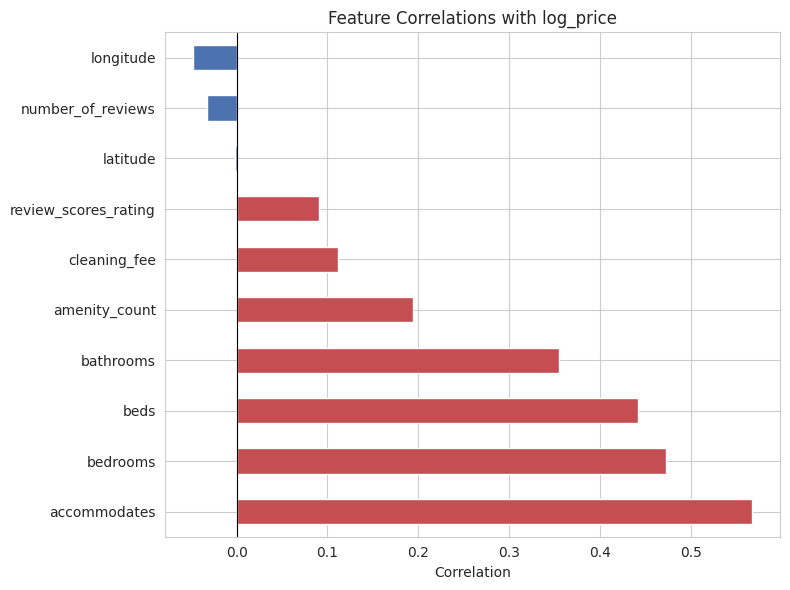

In [61]:
sorted_corr = df[corr_cols].corr()['log_price'].drop('log_price').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sorted_corr.plot(kind='barh', ax=ax, color=['#C44E52' if v > 0 else '#4C72B0' for v in sorted_corr])
ax.set_title('Feature Correlations with log_price')
ax.set_xlabel('Correlation')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [62]:
sorted_corr.round(4)

accommodates            0.5676
bedrooms                0.4732
beds                    0.4422
bathrooms               0.3554
amenity_count           0.1941
cleaning_fee            0.1112
review_scores_rating    0.0912
latitude               -0.0022
number_of_reviews      -0.0325
longitude              -0.0475
Name: log_price, dtype: float64

## 10 · Key Insights

- **Target (`log_price`)** is roughly normal with slight right skew (~0.50) — the log transform does a good job normalizing raw price.
- **Top price drivers**: `accommodates`, `bedrooms`, `bathrooms`, and `amenity_count` show the strongest positive correlations with `log_price`.
- **Room type matters**: Entire home/apt commands a clear premium over private and shared rooms.
- **City differences**: SF and NYC tend to be pricier; location (lat/lon) clusters map clearly to metro areas with distinct price bands.
- **Amenities add value**: listings with more amenities (and specific high-end ones like pool, gym, elevator) average higher prices.
- **Missing data**: `host_response_rate`, `review_scores_rating`, `first_review`, and `last_review` have notable nulls — likely new listings without reviews yet.
- **Cleaning fee** listings are slightly more expensive on average, suggesting hosts bundle premium service.
- **Multicollinearity**: `accommodates`, `bedrooms`, `beds`, and `bathrooms` are inter-correlated — feature selection or regularization will help.
- **Categorical richness**: `amenities` (text blob), `property_type` (36 types), `neighbourhood`, and `zipcode` need encoding strategies (target encoding, frequency, or embeddings).